In [ ]:
# imports, file paths, MODEL_CONFIGS, cuda

import os
import sys
import math
import torch
import random
import numpy as np
import torch.nn as nn
from pathlib import Path
import torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat, einsum


import training_engine as training_engine 
import inference_engine as inference_engine
from rms_norm import RMSNorm



MODEL_CONFIGS = {
    "embed_dim"   : 2**5,   # 32
    "max_seq_len" : 2**6,   # 64
    "vocab_size"  : 2**11,  # 2048
    "num_attn_heads": 1,
   
    "batch_size"  : 2**4,   # 16
    "learning_rate" : 1e-3,

    "save_path" : "../models/level3_single_head_attn.pt",
    "loss_history" : "../models/level3_single_head_attn_loss_history.txt",

}



# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)




cuda


In [3]:
class Level3SingleHeadCausalAttentionModel(nn.Module):

    def __init__(self):
        super().__init__()
        
        self.vocab_size = MODEL_CONFIGS["vocab_size"]
        self.embed_dim = MODEL_CONFIGS["embed_dim"]
        self.max_seq_len = MODEL_CONFIGS["max_seq_len"]



        # --- Embed/Unembed ---

        # Token Embedding lookup (learnable parameters)
        self.embed = nn.Parameter(torch.randn(self.vocab_size, self.embed_dim) * 0.02)

        # Unembedding Projection matrix (learnable parameters)
        self.unembed = nn.Parameter(torch.randn(self.embed_dim, self.vocab_size) * 0.02)



        # --- Positional Encoding ---

        # Pre-computing Fixed Sinusoidal Positional Encodings   
        pos_enc = torch.zeros(self.max_seq_len, self.embed_dim)
        position = torch.arange(0, self.max_seq_len, 
                                dtype=torch.float).unsqueeze(1) # Shape: (max_seq_len, 1)
        
        # Geometric progression division term: 10000^(2i/embed_dim)
        # Operating in log-space for numerical stability
        div_term = torch.exp(torch.arange(0, self.embed_dim, 2).float() 
                             * (-math.log(10000.0) / self.embed_dim)) # Shape: (embed_dim/2)

        # Apply sine to even indices; cosine to odd indices
        pos_enc[:, 0::2] = torch.sin(position * div_term)
        pos_enc[:, 1::2] = torch.cos(position * div_term)

        # Register as buffer: model state, non-learnable, auto-transfers to device
        self.register_buffer('pos_enc', pos_enc)



        # --- RMS Normalization Layer ---
        self.rms_norm_1 = RMSNorm(self.embed_dim)
        self.rms_norm_2 = RMSNorm(self.embed_dim)


        # --- Single Attention Head ---
        self.attn = SingleHeadCausalAttention()



    def forward(self, idx):
        batch_size, seq_len = idx.shape


        # Look up and add fixed positional encodings
        x_token = self.embed[idx]
        x_pos = self.pos_enc[:seq_len, :]

        x_pos = rearrange(self.pos_enc[:seq_len], "seq_len embed_dim -> 1 seq_len embed_dim")
        x = x_token + x_pos  # PyTorch automatically broadcasts the batch dimension of 1 to batch_size

        # Apply Norm before the attention block (Pre-Norm)
        # Pass through the attention block and add via residual connection (+)
        x = x + self.attn(self.rms_norm_1(x))
        x_norm = self.rms_norm_2(x)


        # Project to vocabulary logits
        logits = einsum(x_norm, self.unembed, 
                        "batch_size seq_len embed_dim, embed_dim vocab_size"
                        " -> "
                        "batch_size seq_len vocab_size")
        return logits




In [4]:
class SingleHeadCausalAttention(nn.Module):
    def __init__(self):
        super().__init__()

        self.embed_dim = MODEL_CONFIGS["embed_dim"]
        self.head_dim = self.embed_dim // MODEL_CONFIGS["num_attn_heads"]
        self.scale = self.head_dim ** -0.5

        self.W_query = nn.Parameter(torch.randn(self.embed_dim, self.head_dim) * 0.02)
        self.W_key   = nn.Parameter(torch.randn(self.embed_dim, self.head_dim) * 0.02)
        self.W_value = nn.Parameter(torch.randn(self.embed_dim, self.head_dim) * 0.02)
        self.W_out   = nn.Parameter(torch.randn(self.head_dim, self.embed_dim) * 0.02)


        max_seq = MODEL_CONFIGS["max_seq_len"]
        mask = torch.triu(
            torch.ones(max_seq, max_seq, dtype=torch.bool),
            diagonal=1,
        )
        self.register_buffer("mask", mask)


    def forward(self, x):
        batch_size, seq_len, embed_dim = x.shape

        Q_proj = x @ self.W_query
        K_proj = x @ self.W_key
        V_proj = x @ self.W_value

        scores = einsum(
            Q_proj,
            K_proj,
            "batch query head_dim, batch key head_dim -> batch query key",
        ) * self.scale


        # Masking with -1e9 to prevent NaN issues in FP16/BF16
        scores_masked = scores.masked_fill(
            self.mask[:seq_len, :seq_len],
            -1e9,
        )

        attn = scores_masked.softmax(dim=-1)

        # Weighted sum of values
        context = einsum(
            attn,
            V_proj,
            "batch query key, batch key head_dim -> batch query head_dim",
        )

        out = context @ self.W_out

        return out


Step 0000 | Batch Loss: 7.6316 nats
Step 0005 | Batch Loss: 7.5815 nats
Step 0010 | Batch Loss: 7.5450 nats
Step 0015 | Batch Loss: 7.5064 nats
Step 0020 | Batch Loss: 7.4427 nats
Step 0025 | Batch Loss: 7.3833 nats
Step 0030 | Batch Loss: 7.3402 nats
Step 0035 | Batch Loss: 7.2950 nats
Step 0040 | Batch Loss: 7.2213 nats
Step 0045 | Batch Loss: 7.1981 nats
Step 0050 | Batch Loss: 7.1574 nats
Step 0055 | Batch Loss: 7.1726 nats
Step 0060 | Batch Loss: 7.1578 nats
Step 0065 | Batch Loss: 7.1364 nats
Step 0070 | Batch Loss: 7.1246 nats
Step 0075 | Batch Loss: 7.0950 nats
Step 0080 | Batch Loss: 7.0834 nats
Step 0085 | Batch Loss: 7.0399 nats
Step 0090 | Batch Loss: 7.0392 nats
Step 0095 | Batch Loss: 7.0874 nats
Step 0099 | Batch Loss: 7.0745 nats

Saving model weights to: ../models/level3_single_head_attn.pt
Loss history successfully saved to ../models/level3_single_head_attn_loss_history.txt
Loaded 100 steps from ../models/level3_single_head_attn_loss_history.txt


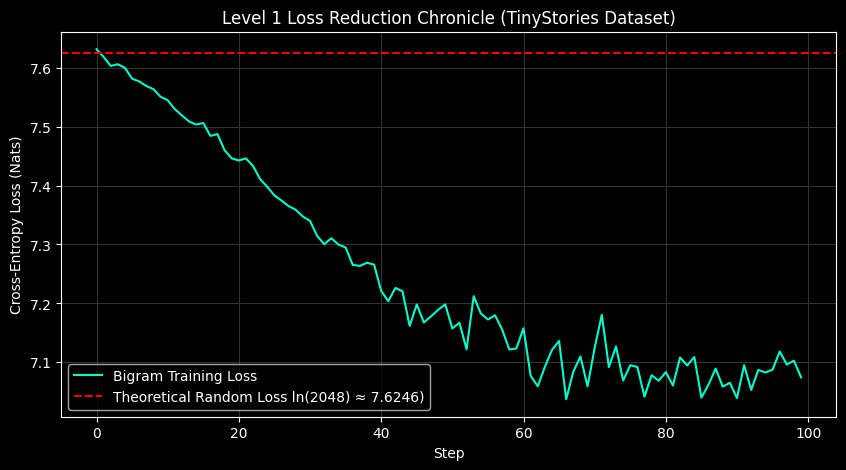

In [8]:
model = Level3SingleHeadCausalAttentionModel()
configs = MODEL_CONFIGS

training_engine.train_and_save_model(model, configs, device, 100)
training_engine.plot_loss_history(configs)
